Today's topics:
* why repeated measurements need a "center" number and a "spread" number
* mean and median, by hand and with NumPy
* variance and standard deviation, by hand and with NumPy

# Two identical bars, two very different lives

In 1954 two de Havilland Comet 1 aircraft, the world's first commercial jet
airliner, broke apart in flight within three months of each other. The cause was
metal fatigue: the fuselage was pressurized on every flight, and cracks grew from
stress concentrations in the skin until it failed.

Here is the part that matters today. A test fuselage had survived far more
pressurization cycles than the aircraft that failed, but it had been proof-tested
first at twice the expected pressure. That overload caused local plastic flow
around the windows and unknowingly extended the test article's life. One passing
specimen cannot establish the life of a fleet.
([NASA, *Exploring in Aeronautics*, NASA-EP-89](https://ntrs.nasa.gov/citations/19750064998))

Here is what that looks like in numbers. These two readings come from a published
fatigue study on 42CrMo4 steel: same campaign, alloy, geometry, surface finish,
loading mode, and 490 MPa stress amplitude. Two different specimens.

In [1]:
bar_1_cycles = 226630
bar_2_cycles = 10895975

print(bar_1_cycles)
print(bar_2_cycles)
print(bar_2_cycles / bar_1_cycles)

226630
10895975
48.07825530600538


One specimen lasted 48 times longer than the other, and neither is marked as a
run-out or an anomalous test.

So if you have to certify this steel, what single number describes its fatigue
life? The average of the two is about 5.6 million cycles, more than 24 times the
shorter life. That is not a number you could promise for every specimen.

A center is not enough. You also need the spread. Today we build both.

([FABEST benchmark fatigue dataset on 42CrMo4+QT steel](https://doi.org/10.5281/zenodo.20967342), CC BY 4.0)

# Warm-up: mean and median by eye

Before the real data, let's do a tiny set we can check in our heads.

In [2]:
import numpy as np

warmup = np.array([2, 4, 4, 6, 9])
print(warmup)
print(f'mean: {np.mean(warmup)}')
print(f'median: {np.median(warmup)}')

[2 4 4 6 9]
mean: 5.0
median: 4.0


The sum is 25 and there are 5 values, so the mean is 5. The sorted middle value
is 4, so that is the median. Notice they already disagree, on five friendly
whole numbers. That gap is going to matter.

# The dataset: 20 hardness readings

Fatigue tests can take weeks. Hardness tests are much quicker and are common in
production quality control. We are going to work with 20 Rockwell C readings
taken at different spots on one piece of heat-treated steel.

<img src="https://upload.wikimedia.org/wikipedia/commons/b/bf/Rockwell_hardness_tester_001.jpg" alt="Rockwell hardness tester" height=250/>

(Three-quarter-ten, [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Rockwell_hardness_tester_001.jpg), [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/))

## Dataset: Repeated Rockwell Hardness (HRC) Readings

**Provenance:** these are synthetic teaching values, designed to resemble repeated
measurements from heat-treated steel. They are not records from a published
experiment.

`hardness` represents 20 Rockwell-C hardness readings at different points on the
*same* specimen. In principle a homogeneous specimen should give the same number
every time, but indentation tests have measurement noise (probe placement, local
microstructure, surface finish), so the simulated readings have a realistic spread.
One reading (index 19) is noticeably higher than the rest -- worth keeping an eye on
as we compare mean and median.

`furnace_A` and `furnace_B` represent 20 readings each from two simulated
heat-treatment batches. Both batches target the same hardness, while batch B was
constructed with substantially more variability. Use them to compare two batches
with (nearly) the same mean but very different spread.

In [3]:
import numpy as np

hardness = np.array([58.2, 57.9, 58.6, 57.5, 58.9, 58.1, 57.8, 58.4, 58.0, 57.6,
                      58.3, 58.7, 57.4, 58.2, 58.5, 57.9, 58.1, 58.8, 57.7, 63.9])

furnace_A = np.array([58.6, 58.5, 58.2, 58.5, 57.9, 57.4, 58.9, 58.4, 57.3, 57.7,
                       57.9, 58.3, 58.8, 58.3, 58.0, 58.4, 58.1, 58.3, 57.9, 57.7])
furnace_B = np.array([58.3, 57.4, 59.5, 56.2, 60.4, 58.0, 57.1, 58.9, 57.7, 56.5,
                       58.6, 59.8, 55.9, 58.3, 59.2, 57.4, 58.0, 60.1, 56.8, 59.5])

print(f'{len(hardness)} hardness readings, units HRC')
print(hardness)

20 hardness readings, units HRC
[58.2 57.9 58.6 57.5 58.9 58.1 57.8 58.4 58.  57.6 58.3 58.7 57.4 58.2
 58.5 57.9 58.1 58.8 57.7 63.9]


In [4]:
print(hardness)
print(len(hardness))

[58.2 57.9 58.6 57.5 58.9 58.1 57.8 58.4 58.  57.6 58.3 58.7 57.4 58.2
 58.5 57.9 58.1 58.8 57.7 63.9]
20


*Why would 20 readings on the same specimen differ at all?*

The indenter samples a different microstructural neighborhood every time, and the
local mixture of martensite, retained austenite, and other features varies.
Surface preparation varies too, and the machine has finite repeatability.

So spread is often signal rather than noise. It can tell you something real about
how uniform your heat treatment was.

Most of these values cluster in the high 57s and 58s. The last reading, 63.9,
stands well clear of the rest.

*Is that a surface artifact, or is it real heterogeneity in the material?*
Statistics can flag the reading as unusual. Deciding what caused it takes
materials knowledge, and we will come back to that.

# Mean: the balance point

*What does the mean actually do, mathematically?*

$$\bar{x} = \frac{1}{N}\sum_{i=1}^N x_i$$

Add everything up, divide by how many there are. Let's do it the long way first
so the formula is not just notation:

In [5]:
total = np.sum(hardness)
N = len(hardness)
mean_by_hand = total / N
print(f'sum: {total}')
print(f'N:   {N}')
print(f'mean (by hand): {mean_by_hand:.4f}')

sum: 1168.5000000000002
N:   20
mean (by hand): 58.4250


[`np.mean`](https://numpy.org/doc/stable/reference/generated/numpy.mean.html)
does the same arithmetic in one call:

In [6]:
print(f'mean (np.mean): {np.mean(hardness):.4f}')

mean (np.mean): 58.4250


The reason people call the mean a balance point is that it is literally where
the data would balance if each reading were a weight on a ruler:

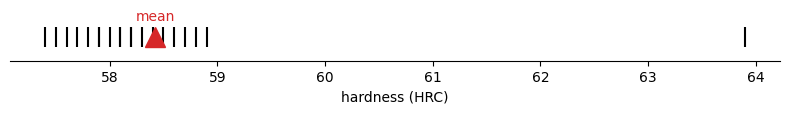

In [7]:
#@title Visualization: mean as balance point (click ▶ to run) { display-mode: "form" }
import matplotlib.pyplot as plt

_mu = np.mean(hardness)
fig, ax = plt.subplots(figsize=(8, 1.2))
ax.scatter(hardness, [0]*len(hardness), marker='|', s=200, color='black', zorder=2)
ax.plot(_mu, 0, marker='^', markersize=14, color='C3', zorder=3, clip_on=False)
ax.annotate('mean', (_mu, 0), textcoords='offset points', xytext=(0, 12),
            ha='center', fontsize=10, color='C3')
ax.set_yticks([])
ax.set_xlabel('hardness (HRC)')
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.show()

## Is the mean sensitive to unusual values?

Let's find out by making that one high reading much worse. We will copy the
array first so we do not destroy the original. The second line uses indexed
assignment: `array[i] = value` replaces the entry at position `i`.

In [8]:
hardness_inflated = hardness.copy()   # .copy() makes an independent copy
hardness_inflated[-1] = 78.5
print(hardness_inflated)

[58.2 57.9 58.6 57.5 58.9 58.1 57.8 58.4 58.  57.6 58.3 58.7 57.4 58.2
 58.5 57.9 58.1 58.8 57.7 78.5]


One value out of twenty changed, and we will see the mean move with it. A single
heavy weight drags the balance point toward itself.

# Median: the middle value

The median takes a different approach. Instead of adding everything up, it sorts
the data and walks to the middle. So sort first:

In [9]:
sorted_hardness = np.sort(hardness)
print(sorted_hardness)

[57.4 57.5 57.6 57.7 57.8 57.9 57.9 58.  58.1 58.1 58.2 58.2 58.3 58.4
 58.5 58.6 58.7 58.8 58.9 63.9]


We have 20 readings, which is an even number, so there is no single middle
entry. The convention is to average the two that straddle the middle, at
positions 9 and 10:

In [10]:
lower_mid = sorted_hardness[9]
upper_mid = sorted_hardness[10]
median_by_hand = (lower_mid + upper_mid) / 2
print(f'lower middle value: {lower_mid}')
print(f'upper middle value: {upper_mid}')
print(f'median (by hand): {median_by_hand:.4f}')

lower middle value: 58.1
upper middle value: 58.2
median (by hand): 58.1500


With an odd number of readings there is a single middle entry and no averaging
is needed.

[`np.median`](https://numpy.org/doc/stable/reference/generated/numpy.median.html)
handles both cases:

In [11]:
print(f'median (np.median): {np.median(hardness):.4f}')

median (np.median): 58.1500


## Does the median react the same way the mean did?

Now let's put them side by side, original against inflated:

In [12]:
print(f'original -- mean: {np.mean(hardness):.4f}, median: {np.median(hardness):.4f}')
print(f'inflated -- mean: {np.mean(hardness_inflated):.4f}, median: {np.median(hardness_inflated):.4f}')

original -- mean: 58.4250, median: 58.1500
inflated -- mean: 59.1550, median: 58.1500


The mean jumped and the median barely budged. We call that **robustness**: the
median only cares about the rank order of the values, not how far out the
extreme one sits.

It is worth noticing that even on the original data the mean is above the
median. That 63.9 reading is already pulling on it.

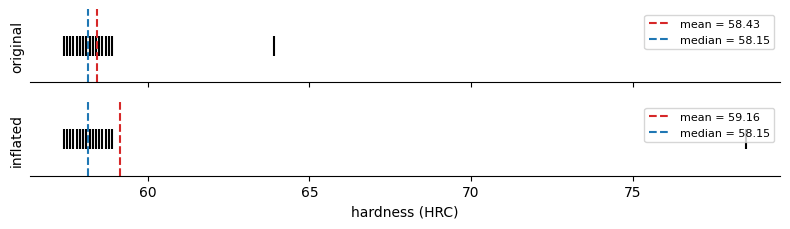

In [13]:
#@title Visualization: mean vs median with outlier (click ▶ to run) { display-mode: "form" }
fig, axes = plt.subplots(2, 1, figsize=(8, 2.4), sharex=True)
for ax, data, label in zip(axes, [hardness, hardness_inflated], ['original', 'inflated']):
    ax.scatter(data, [0]*len(data), marker='|', s=200, color='black', zorder=2)
    ax.axvline(np.mean(data), color='C3', linestyle='--', label=f'mean = {np.mean(data):.2f}')
    ax.axvline(np.median(data), color='C0', linestyle='--', label=f'median = {np.median(data):.2f}')
    ax.set_ylabel(label, fontsize=10)
    ax.set_yticks([])
    ax.legend(fontsize=8, loc='upper right')
    ax.spines[['top', 'right', 'left']].set_visible(False)
axes[1].set_xlabel('hardness (HRC)')
plt.tight_layout()
plt.show()

### [Check your understanding]

We pushed one reading up. Now push one down and see if the same thing happens.

In the code cell below:

1. Make a fresh copy of `hardness` using `.copy()`
2. Set the reading at index 0 to `40.0`
3. Print the mean and median of both the original and your modified copy
4. Which statistic moved more? Does that match what a single low outlier should do?

*Optional challenge*

5. How far down would you have to drag that one reading to move the median by a
   full point? Try a few values and see.

# Mode: the most common value

The third "center" you will hear about is the mode, the value that appears most
often. In `[0, 1, 2, 3, 3]` the mode is 3.

There is no `np.mode`, and for continuous measurements the answer depends on
reporting precision. Our hardness values are rounded to tenths and several tie.
The mode earns its keep on repeated categories, not on measurements like these.

# Variance: average squared deviation from the mean

We have three ways to describe the center, and none says anything about spread,
which is the missing piece in the certification problem we opened with.

*So how far is each reading from the mean?*

Build the **deviation** array, each reading minus the mean. This is elementwise
subtraction, from two lectures ago:

In [14]:
mu = np.mean(hardness)
deviations = hardness - mu
print(deviations)

[-0.225 -0.525  0.175 -0.925  0.475 -0.325 -0.625 -0.025 -0.425 -0.825
 -0.125  0.275 -1.025 -0.225  0.075 -0.525 -0.325  0.375 -0.725  5.475]


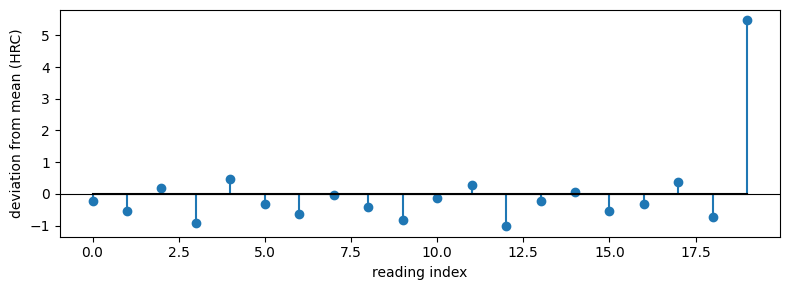

In [15]:
#@title Visualization: deviations from the mean (click ▶ to run) { display-mode: "form" }
fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(range(len(deviations)), deviations, basefmt='k-', linefmt='C0-', markerfmt='C0o',
        label='deviation')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('reading index')
ax.set_ylabel('deviation from mean (HRC)')
plt.tight_layout()
plt.show()

Some deviations are positive and some are negative. The obvious next move is to
average them. Let's try it:

In [16]:
print(f'mean deviation: {np.mean(deviations):.6f}')

mean deviation: -0.000000


Zero. And it is not a coincidence, it will be zero every single time. That is
what "balance point" means: the positive and negative deviations cancel exactly.
So the average deviation can never measure spread, no matter what data you feed
it.

The fix is to get rid of the signs by squaring before averaging. That gives us
the **variance**:

$$\sigma^2 = \frac{1}{N}\sum_{i=1}^N (x_i - \bar{x})^2$$

In [17]:
squared_deviations = deviations ** 2
print(squared_deviations)

variance_by_hand = np.sum(squared_deviations) / N
print(f'variance (by hand): {variance_by_hand:.4f}')

[5.0625000e-02 2.7562500e-01 3.0625000e-02 8.5562500e-01 2.2562500e-01
 1.0562500e-01 3.9062500e-01 6.2500000e-04 1.8062500e-01 6.8062500e-01
 1.5625000e-02 7.5625000e-02 1.0506250e+00 5.0625000e-02 5.6250000e-03
 2.7562500e-01 1.0562500e-01 1.4062500e-01 5.2562500e-01 2.9975625e+01]
variance (by hand): 1.7509


[`np.var`](https://numpy.org/doc/stable/reference/generated/numpy.var.html)
again does the same thing:

In [18]:
print(f'variance (np.var): {np.var(hardness):.4f}')

variance (np.var): 1.7509


One thing to watch for. NumPy divides by N by default, the population variance.
Your statistics textbook may divide by N-1, the sample variance, which you get
with `np.var(data, ddof=1)`.

Dividing by N says these 20 readings are the whole story and you are describing
this specimen. Dividing by N-1 says they sample a larger process and you are
estimating the batch. The science decides, not the software.

There is one more problem with variance, and it is a units problem. We squared
the deviations, so we squared the units along with them. Our variance is in
$\mathrm{HRC}^2$, and $\mathrm{HRC}^2$ is not on any spec sheet anywhere.

# Standard deviation: back to original units

Take the square root and the units come back:

$$\sigma = \sqrt{\sigma^2} = \sqrt{\frac{1}{N}\sum_{i=1}^N (x_i - \bar{x})^2}$$

In [19]:
std_by_hand = np.sqrt(variance_by_hand)
print(f'standard deviation (by hand): {std_by_hand:.4f}')

standard deviation (by hand): 1.3232


[`np.std`](https://numpy.org/doc/stable/reference/generated/numpy.std.html):

In [20]:
print(f'standard deviation (np.std): {np.std(hardness):.4f}')

standard deviation (np.std): 1.3232


Now the spread is back in units an engineer would recognize. As a descriptive
shorthand, we can print the mean plus or minus one standard deviation. This is
not a specification interval or a guarantee about how many readings it contains:

In [21]:
mu = np.mean(hardness)
sigma = np.std(hardness)
print(f'typical range: {mu - sigma:.2f} to {mu + sigma:.2f} HRC')

typical range: 57.10 to 59.75 HRC


### [Check your understanding]

In the code cell below, work out the variance and standard deviation of the
`warmup` array from the start of class, `[2, 4, 4, 6, 9]`, without calling
`np.var` or `np.std`.

1. Compute the mean
2. Build the deviation array by subtracting the mean
3. Square the deviations and average them, that is the variance
4. Take `np.sqrt` of the variance, that is the standard deviation
5. Check yourself against `np.var` and `np.std`

*Optional challenge*

6. Now compute it again with `ddof=1` and compare. With only 5 values, how big is
   the difference between dividing by N and dividing by N-1?

# Same mean, very different spread

Here is where all of this pays off. Two furnaces are running the same heat
treatment on the same steel, aiming for the same target hardness. Twenty parts
were measured out of each.

In [22]:
print(f'furnace A -- mean: {np.mean(furnace_A):.2f}, std: {np.std(furnace_A):.4f}')
print(f'furnace B -- mean: {np.mean(furnace_B):.2f}, std: {np.std(furnace_B):.4f}')

furnace A -- mean: 58.16, std: 0.4201
furnace B -- mean: 58.18, std: 1.2848


The means agree to within about 0.02 HRC. If the only number on your report were
the mean, these two furnaces would look interchangeable.

The standard deviations are not close at all. Furnace B's is roughly three times
furnace A's.

Now suppose the customer's target is 58.2 HRC and the specification is that
target plus or minus 1 HRC.
Let's look at the extremes each furnace actually produced, using `np.min` and
`np.max` from two lectures ago:

In [23]:
print(f'furnace A -- min: {np.min(furnace_A)}, max: {np.max(furnace_A)}')
print(f'furnace B -- min: {np.min(furnace_B)}, max: {np.max(furnace_B)}')

furnace A -- min: 57.3, max: 58.9
furnace B -- min: 55.9, max: 60.4


Furnace A's parts run from 57.3 to 58.9, a total spread of 1.6 HRC, so every one
of its 20 parts sits inside the 57.2-to-59.2 specification band. Furnace B runs
from 55.9 to 60.4, a spread of 4.5 HRC. Only 10 of its 20 parts land inside the
same inclusive band, so it is scrapping half its output while reporting an
excellent average.

This is the whole lesson of the hour in one comparison. The mean told you the
furnaces were the same. The standard deviation told you which one you can ship.

## An automated summary

You will not always want to call four separate functions. SciPy has a function
that reports several of these at once. You do not need to learn it, and it will
not be on an assignment, but it is worth seeing that it exists:

In [24]:
#@title Optional tool glimpse: scipy.stats.describe (click ▶ to run) { display-mode: "form" }
from scipy.stats import describe

summary = describe(hardness, ddof=0)
print(summary)

DescribeResult(nobs=np.int64(20), minmax=(np.float64(57.4), np.float64(63.9)), mean=np.float64(58.42500000000001), variance=np.float64(1.7508749999999993), skewness=np.float64(3.470099581326962), kurtosis=np.float64(11.704569127179393))


Compare `nobs`, `minmax`, `mean`, and `variance` against our hand calculations.
They match.

Notice we had to pass `ddof=0` to get that agreement, because this function
divides by N-1 unless you tell it otherwise. A tool that automates your
arithmetic still expects you to know which convention you wanted. It also
reports skewness and kurtosis, which are two more shape numbers we are not
covering.

### [Check your understanding]

A supplier's certificate of analysis reports summary statistics for a batch of
10 parts, but never the individual measurements. Your job is to work backward.

In the code cells below, build **two** different 10-value arrays that both have a
mean of 58.0:

1. One tightly clustered, with every value between 57 and 59
2. One spread as widely as you can manage, with every value between 40 and 76

Print the mean and standard deviation of each to check yourself.

Both arrays pass a certificate that reports only the mean. Only one of them is a
batch you would want to receive.

## One number is never enough

We built four numbers today, and the useful part is what they cannot do alone.

The mean gets dragged around by one bad reading. The median ignores how far out
that reading was. Neither says anything about consistency, which is what furnace
B failed at and what a fleet-certification test must establish.

A center tells you where the material sits. A spread tells you whether you can
count on it. Reporting one without the other is how two furnaces look identical
on paper and only one of them ships.

## Further reading

- [VanderPlas: Aggregations (min, max, and everything in between)](https://jakevdp.github.io/PythonDataScienceHandbook/02.04-computation-on-arrays-aggregates.html)
- [McKinney: NumPy basics](https://wesmckinney.com/book/numpy-basics) (descriptive statistics section)